# Hypermut3 Pairwise Results Analysis

> Current decision rule: use raw Fisher p-values only (`fisher_p < 0.05`) to identify possible hypermutation.

This notebook also derives:
- `accession_number` from `seq_header` token 4 (index 3)
- `cluster_id` from `final_group_key` (`ClusterId=...`)
- `mutation_direction` in the form `A > T`

> Note: FDR-adjusted outputs are intentionally excluded for this iteration.

In [16]:
import pandas as pd

# 1. Define the labels from your screenshot in the correct order
LANL_LABELS = [
    'Se_ID', 'Patient_Code', 'PAT_id_SSAM', 'Accession', 
    'Name', 'Subtype', 'Country', 'Sampling_Year', 
    'Problematic_Sequence', 'HXB2_MAC239_start', 
    'HXB2_MAC239_stop', 'Sequence_Length', 'Organism'
]

# 2. Load your data
input_file = 'data/hypermute3_pairwise_results/per_sequence_hypermut_merged_for_initial_showing.csv'
df = pd.read_csv(input_file)

# 3. Split the 'seq_header' column
# We split by comma and expand it into new columns
split_headers = df['seq_header'].str.split(',', expand=True)

# 4. Assign the labels as column names
split_headers.columns = LANL_LABELS

# 5. Combine back with the original data
# We drop the old 'seq_header' and 'seq_name' (which seems to be a duplicate)
df_final = pd.concat([split_headers, df.drop(columns=['seq_header', 'seq_name'])], axis=1)

# 6. Save the new expanded CSV
output_file = 'data/hypermute3_pairwise_results/per_sequence_hypermut_expanded.csv'
df_final.to_csv(output_file, index=False)

print(f"Successfully expanded seq_header. New file saved to: {output_file}")
# print(df_final.head())

Successfully expanded seq_header. New file saved to: data/hypermute3_pairwise_results/per_sequence_hypermut_expanded.csv


In [8]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Display settings for easier inspection
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 180)

def resolve_path(path_str: str) -> Path:
    p = Path(path_str)
    if p.exists():
        return p
    # Fallback for notebooks launched from subfolders.
    candidate = Path.cwd() / path_str
    return candidate

DATA_PATH = resolve_path('data/hypermute3_pairwise_results/per_sequence_hypermut_merged_for_initial_showing.csv')
GROUP_MANIFEST_PATH = resolve_path('data/processed_grouped/group_manifest.csv')
ALPHA = 0.05

print(f"Input file: {DATA_PATH}")
print(f"Input exists: {DATA_PATH.exists()}")
print(f"Group manifest: {GROUP_MANIFEST_PATH}")
print(f"Group manifest exists: {GROUP_MANIFEST_PATH.exists()}")
print(f"Raw Fisher threshold (alpha): {ALPHA}")

Input file: data/hypermute3_pairwise_results/per_sequence_hypermut_merged_for_initial_showing.csv
Input exists: True
Group manifest: data/processed_grouped/group_manifest.csv
Group manifest exists: True
Raw Fisher threshold (alpha): 0.05


In [9]:
required_columns = {
    'seq_header',
    'final_group_key',
    'consensus_header',
    'pair_aligned_fasta',
    'run_name',
    'match',
    'keepgaps',
    'mutation_from',
    'mutation_to',
    'primary_matches',
    'potential_primaries',
    'control_matches',
    'potential_controls',
    'rate_ratio',
    'fisher_p',
}

if not DATA_PATH.exists():
    raise FileNotFoundError(f"Input CSV not found: {DATA_PATH}")

df_raw = pd.read_csv(DATA_PATH)
missing = sorted(required_columns - set(df_raw.columns))
if missing:
    raise ValueError(f"Missing required columns: {missing}")

print(f"Rows: {len(df_raw):,}")
print(f"Columns: {len(df_raw.columns):,}")
print("Required columns present: OK")
df_raw.head(3)

Rows: 288,768
Columns: 18
Required columns present: OK


,seq_header,final_group_key,consensus_header,pair_aligned_fasta,run_name,match,keepgaps,mutation_from,mutation_to,seq_name,primary_matches,potential_primaries,control_matches,potential_controls,rate_ratio,fisher_p,summary_csv,positions_csv
0,"156744,-,-,AF000462,IC3734,A,CI,1995,0,7050,74...",Donor=-|RegionId=1|BinId=194,Consensus|group_194|Donor=-|RegionId=1|BinId=1...,/Users/ron/Developer/CQUniversity/concensus_hi...,strict-keepgaps,strict,True,A,C,"156744,-,-,AF000462,IC3734,A,CI,1995,0,7050,74...",1.0,61.0,5.0,87.0,0.29,0.961664,/Users/ron/Developer/CQUniversity/concensus_hi...,/Users/ron/Developer/CQUniversity/concensus_hi...
1,"156744,-,-,AF000462,IC3734,A,CI,1995,0,7050,74...",Donor=-|RegionId=1|BinId=194,Consensus|group_194|Donor=-|RegionId=1|BinId=1...,/Users/ron/Developer/CQUniversity/concensus_hi...,strict-skipgaps,strict,False,A,C,"156744,-,-,AF000462,IC3734,A,CI,1995,0,7050,74...",1.0,61.0,5.0,89.0,0.29,0.959355,/Users/ron/Developer/CQUniversity/concensus_hi...,/Users/ron/Developer/CQUniversity/concensus_hi...
2,"156744,-,-,AF000462,IC3734,A,CI,1995,0,7050,74...",Donor=-|RegionId=1|BinId=194,Consensus|group_194|Donor=-|RegionId=1|BinId=1...,/Users/ron/Developer/CQUniversity/concensus_hi...,partial-keepgaps,partial,True,A,C,"156744,-,-,AF000462,IC3734,A,CI,1995,0,7050,74...",1.0,61.0,5.0,87.0,0.29,0.961664,/Users/ron/Developer/CQUniversity/concensus_hi...,/Users/ron/Developer/CQUniversity/concensus_hi...


In [10]:
df = df_raw.copy()

numeric_columns = [
    'primary_matches',
    'potential_primaries',
    'control_matches',
    'potential_controls',
    'rate_ratio',
    'fisher_p',
]

for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Normalize keepgaps to bool for stable grouping
keepgaps_map = {
    'true': True,
    'false': False,
    True: True,
    False: False,
}
df['keepgaps_bool'] = df['keepgaps'].map(lambda x: keepgaps_map.get(str(x).strip().lower(), np.nan))

# Derive accession number from seq_header token 4 (index 3)
def extract_accession(seq_header: str):
    if pd.isna(seq_header):
        return np.nan
    parts = [p.strip() for p in str(seq_header).split(',')]
    return parts[3] if len(parts) > 3 else np.nan

# Derive cluster_id from final_group_key token ClusterId=...
def extract_cluster_id(final_group_key: str):
    if pd.isna(final_group_key):
        return np.nan
    for token in str(final_group_key).split('|'):
        if token.startswith('ClusterId='):
            return token.split('=', 1)[1].strip()
    return np.nan

df['final_group_key'] = df['final_group_key'].astype(str).str.strip()
df['accession_number'] = df['seq_header'].apply(extract_accession)
df['cluster_id'] = df['final_group_key'].apply(extract_cluster_id)
df['mutation_direction'] = df['mutation_from'].astype(str) + ' > ' + df['mutation_to'].astype(str)

# Canonical test identifier for each run/mutation context
df['test_id'] = (
    df['seq_header'].astype(str)
    + '||' + df['run_name'].astype(str)
    + '||' + df['mutation_direction'].astype(str)
)

# Link each row back to the source group FASTA used before pairwise step.
if GROUP_MANIFEST_PATH.exists():
    group_manifest = pd.read_csv(GROUP_MANIFEST_PATH)
    required_manifest_cols = {'full_key', 'group_id', 'raw_fasta', 'aligned_fasta'}
    missing_manifest = sorted(required_manifest_cols - set(group_manifest.columns))
    if missing_manifest:
        raise ValueError(f"Missing columns in group manifest: {missing_manifest}")

    group_manifest['final_group_key'] = group_manifest['full_key'].astype(str).str.rsplit('|n=', n=1).str[0].str.strip()
    group_manifest = group_manifest.rename(columns={
        'raw_fasta': 'source_group_raw_fasta',
        'aligned_fasta': 'source_group_aligned_fasta',
    })

    group_lookup = group_manifest[['group_id', 'final_group_key', 'source_group_raw_fasta', 'source_group_aligned_fasta']].drop_duplicates()
    df = df.merge(group_lookup, on='final_group_key', how='left')

    mapped = int(df['source_group_aligned_fasta'].notna().sum())
    print(f"Group-source mapping coverage: {mapped}/{len(df)} rows mapped")
else:
    df['group_id'] = np.nan
    df['source_group_raw_fasta'] = np.nan
    df['source_group_aligned_fasta'] = np.nan
    print('Group manifest not found in current notebook working directory context.')

parse_report = pd.DataFrame({
    'column': numeric_columns + ['accession_number', 'cluster_id'],
    'n_null_after_parse': [int(df[c].isna().sum()) for c in (numeric_columns + ['accession_number', 'cluster_id'])],
})

print('Numeric/field parse report:')
display(parse_report)

print(f"Accession extraction nulls: {int(df['accession_number'].isna().sum())}")
print(f"Cluster extraction nulls: {int(df['cluster_id'].isna().sum())}")
print('Example source-trace preview (pre-pairwise group FASTA + pairwise FASTA):')
display(df[['seq_header', 'group_id', 'source_group_aligned_fasta', 'source_group_raw_fasta', 'pair_aligned_fasta']].head(8))

Group-source mapping coverage: 288768/288768 rows mapped
Numeric/field parse report:


,column,n_null_after_parse
0,primary_matches,0
1,potential_primaries,0
2,control_matches,0
3,potential_controls,0
4,rate_ratio,192144
5,fisher_p,0
6,accession_number,0
7,cluster_id,288768


Accession extraction nulls: 0
Cluster extraction nulls: 288768
Example source-trace preview (pre-pairwise group FASTA + pairwise FASTA):


,seq_header,group_id,source_group_aligned_fasta,source_group_raw_fasta,pair_aligned_fasta
0,"156744,-,-,AF000462,IC3734,A,CI,1995,0,7050,74...",group_194,/Users/ron/Developer/CQUniversity/concensus_hi...,/Users/ron/Developer/CQUniversity/concensus_hi...,/Users/ron/Developer/CQUniversity/concensus_hi...
1,"156744,-,-,AF000462,IC3734,A,CI,1995,0,7050,74...",group_194,/Users/ron/Developer/CQUniversity/concensus_hi...,/Users/ron/Developer/CQUniversity/concensus_hi...,/Users/ron/Developer/CQUniversity/concensus_hi...
2,"156744,-,-,AF000462,IC3734,A,CI,1995,0,7050,74...",group_194,/Users/ron/Developer/CQUniversity/concensus_hi...,/Users/ron/Developer/CQUniversity/concensus_hi...,/Users/ron/Developer/CQUniversity/concensus_hi...
3,"156744,-,-,AF000462,IC3734,A,CI,1995,0,7050,74...",group_194,/Users/ron/Developer/CQUniversity/concensus_hi...,/Users/ron/Developer/CQUniversity/concensus_hi...,/Users/ron/Developer/CQUniversity/concensus_hi...
4,"156744,-,-,AF000462,IC3734,A,CI,1995,0,7050,74...",group_194,/Users/ron/Developer/CQUniversity/concensus_hi...,/Users/ron/Developer/CQUniversity/concensus_hi...,/Users/ron/Developer/CQUniversity/concensus_hi...
5,"156744,-,-,AF000462,IC3734,A,CI,1995,0,7050,74...",group_194,/Users/ron/Developer/CQUniversity/concensus_hi...,/Users/ron/Developer/CQUniversity/concensus_hi...,/Users/ron/Developer/CQUniversity/concensus_hi...
6,"156744,-,-,AF000462,IC3734,A,CI,1995,0,7050,74...",group_194,/Users/ron/Developer/CQUniversity/concensus_hi...,/Users/ron/Developer/CQUniversity/concensus_hi...,/Users/ron/Developer/CQUniversity/concensus_hi...
7,"156744,-,-,AF000462,IC3734,A,CI,1995,0,7050,74...",group_194,/Users/ron/Developer/CQUniversity/concensus_hi...,/Users/ron/Developer/CQUniversity/concensus_hi...,/Users/ron/Developer/CQUniversity/concensus_hi...


In [11]:
# Raw Fisher significance only
df['is_significant'] = df['fisher_p'] < ALPHA

overall_summary = pd.DataFrame({
    'metric': [
        'n_rows',
        'n_unique_sequences',
        'n_unique_accessions',
        'n_unique_clusters',
        'n_significant_raw',
        'pct_significant_raw',
    ],
    'value': [
        len(df),
        df['seq_header'].nunique(),
        df['accession_number'].nunique(),
        df['cluster_id'].nunique(),
        int(df['is_significant'].sum()),
        round(100 * df['is_significant'].mean(), 3),
    ]
})

print('Overall raw-significance summary:')
display(overall_summary)

print('Fisher p-value distribution checks:')
print(f"min fisher_p: {df['fisher_p'].min():.6g}")
print(f"median fisher_p: {df['fisher_p'].median():.6g}")
print(f"max fisher_p: {df['fisher_p'].max():.6g}")

Overall raw-significance summary:


,metric,value
0,n_rows,288768.000
1,n_unique_sequences,6016.000
2,n_unique_accessions,6016.000
3,n_unique_clusters,0.000
4,n_significant_raw,690.000
5,pct_significant_raw,0.239


Fisher p-value distribution checks:
min fisher_p: 7.55403e-08
median fisher_p: 1
max fisher_p: 1


Raw-significant results by run configuration:


,run_name,match,keepgaps_bool,n_tests,n_sequences,n_accessions,n_raw_sig,pct_raw_sig
1,partial-skipgaps,partial,False,72192,6016,6016,173,0.239639
3,strict-skipgaps,strict,False,72192,6016,6016,173,0.239639
0,partial-keepgaps,partial,True,72192,6016,6016,172,0.238254
2,strict-keepgaps,strict,True,72192,6016,6016,172,0.238254


Hypermutations by mutation direction (raw fisher_p < 0.05):


,mutation_direction,n_tests,n_hypermutations,pct_hypermutations,min_fisher_p,median_fisher_p
1,A > G,24064,170,0.706449,2.665540e-04,1.0
6,G > A,24064,140,0.581782,7.554030e-08,1.0
0,A > C,24064,74,0.307513,4.415690e-03,1.0
3,C > A,24064,62,0.257646,1.034280e-02,1.0
7,G > C,24064,50,0.207779,5.454450e-03,1.0
5,C > T,24064,44,0.182846,9.151460e-04,1.0
4,C > G,24064,42,0.174535,1.558760e-03,1.0
8,G > T,24064,28,0.116356,1.120160e-02,1.0
10,T > C,24064,28,0.116356,2.275990e-03,1.0
2,A > T,24064,18,0.074801,1.124950e-02,1.0


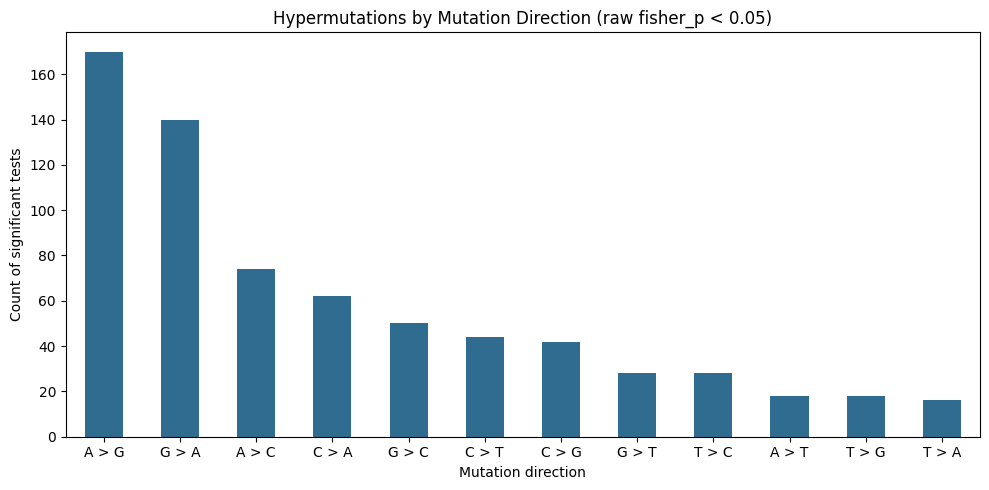

In [12]:
summary_by_run = (
    df.groupby(['run_name', 'match', 'keepgaps_bool'], dropna=False)
      .agg(
          n_tests=('test_id', 'count'),
          n_sequences=('seq_header', 'nunique'),
          n_accessions=('accession_number', 'nunique'),
          n_raw_sig=('is_significant', 'sum'),
      )
      .reset_index()
)
summary_by_run['pct_raw_sig'] = 100 * summary_by_run['n_raw_sig'] / summary_by_run['n_tests']

direction_summary = (
    df.groupby(['mutation_direction'], dropna=False)
      .agg(
          n_tests=('test_id', 'count'),
          n_hypermutations=('is_significant', 'sum'),
          pct_hypermutations=('is_significant', lambda x: 100 * x.mean()),
          min_fisher_p=('fisher_p', 'min'),
          median_fisher_p=('fisher_p', 'median'),
      )
      .reset_index()
      .sort_values(['n_hypermutations', 'n_tests'], ascending=False)
)

print('Raw-significant results by run configuration:')
display(summary_by_run.sort_values(['n_raw_sig', 'n_tests'], ascending=False))

print('Hypermutations by mutation direction (raw fisher_p < 0.05):')
display(direction_summary)

ax = direction_summary.plot(
    kind='bar',
    x='mutation_direction',
    y='n_hypermutations',
    figsize=(10, 5),
    color='#2F6C8F',
    legend=False,
    title='Hypermutations by Mutation Direction (raw fisher_p < 0.05)'
)
ax.set_xlabel('Mutation direction')
ax.set_ylabel('Count of significant tests')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [13]:
possible_hypermutation = (
    df.loc[df['is_significant']]
      .copy()
      .sort_values(['fisher_p', 'rate_ratio'], ascending=[True, False])
)

# Compact output requested for quick accession lookup + source traceability
candidates_export = (
    possible_hypermutation[[
        'accession_number',
        'cluster_id',
        'group_id',
        'source_group_aligned_fasta',
        'source_group_raw_fasta',
        'pair_aligned_fasta',
        'consensus_header',
        'mutation_direction',
        'fisher_p',
    ]]
    .rename(columns={
        'pair_aligned_fasta': 'pairwise_aligned_fasta',
        'consensus_header': 'consensus',
        'fisher_p': 'p_fisher',
    })
)

print(f"Candidate rows (raw fisher_p < 0.05): {len(candidates_export):,}")
print(f"Unique candidate accessions: {candidates_export['accession_number'].nunique():,}")
display(candidates_export.head(50))

# Manual accession extraction check sample
check_sample = df[['seq_header', 'accession_number']].drop_duplicates().head(10).copy()
check_sample['seq_header_token_4'] = check_sample['seq_header'].str.split(',').str[3].str.strip()
check_sample['matches_expected_token_4'] = check_sample['accession_number'] == check_sample['seq_header_token_4']

print('Accession extraction verification sample:')
display(check_sample)

Candidate rows (raw fisher_p < 0.05): 690
Unique candidate accessions: 168


,accession_number,cluster_id,group_id,source_group_aligned_fasta,source_group_raw_fasta,pairwise_aligned_fasta,consensus,mutation_direction,p_fisher
89736,AY036363,NaN,group_239,/Users/ron/Developer/CQUniversity/concensus_hi...,/Users/ron/Developer/CQUniversity/concensus_hi...,/Users/ron/Developer/CQUniversity/concensus_hi...,Consensus|group_239|Donor=10362|RegionId=1|Bin...,G > A,7.554030e-08
89737,AY036363,NaN,group_239,/Users/ron/Developer/CQUniversity/concensus_hi...,/Users/ron/Developer/CQUniversity/concensus_hi...,/Users/ron/Developer/CQUniversity/concensus_hi...,Consensus|group_239|Donor=10362|RegionId=1|Bin...,G > A,7.554030e-08
89738,AY036363,NaN,group_239,/Users/ron/Developer/CQUniversity/concensus_hi...,/Users/ron/Developer/CQUniversity/concensus_hi...,/Users/ron/Developer/CQUniversity/concensus_hi...,Consensus|group_239|Donor=10362|RegionId=1|Bin...,G > A,7.554030e-08
89739,AY036363,NaN,group_239,/Users/ron/Developer/CQUniversity/concensus_hi...,/Users/ron/Developer/CQUniversity/concensus_hi...,/Users/ron/Developer/CQUniversity/concensus_hi...,Consensus|group_239|Donor=10362|RegionId=1|Bin...,G > A,7.554030e-08
89304,AY036324,NaN,group_237,/Users/ron/Developer/CQUniversity/concensus_hi...,/Users/ron/Developer/CQUniversity/concensus_hi...,/Users/ron/Developer/CQUniversity/concensus_hi...,Consensus|group_237|Donor=10357|RegionId=1|Bin...,G > A,1.220750e-07
89305,AY036324,NaN,group_237,/Users/ron/Developer/CQUniversity/concensus_hi...,/Users/ron/Developer/CQUniversity/concensus_hi...,/Users/ron/Developer/CQUniversity/concensus_hi...,Consensus|group_237|Donor=10357|RegionId=1|Bin...,G > A,1.220750e-07
89306,AY036324,NaN,group_237,/Users/ron/Developer/CQUniversity/concensus_hi...,/Users/ron/Developer/CQUniversity/concensus_hi...,/Users/ron/Developer/CQUniversity/concensus_hi...,Consensus|group_237|Donor=10357|RegionId=1|Bin...,G > A,1.220750e-07
89307,AY036324,NaN,group_237,/Users/ron/Developer/CQUniversity/concensus_hi...,/Users/ron/Developer/CQUniversity/concensus_hi...,/Users/ron/Developer/CQUniversity/concensus_hi...,Consensus|group_237|Donor=10357|RegionId=1|Bin...,G > A,1.220750e-07
89928,AY036373,NaN,group_240,/Users/ron/Developer/CQUniversity/concensus_hi...,/Users/ron/Developer/CQUniversity/concensus_hi...,/Users/ron/Developer/CQUniversity/concensus_hi...,Consensus|group_240|Donor=10363|RegionId=1|Bin...,G > A,1.655430e-07
89929,AY036373,NaN,group_240,/Users/ron/Developer/CQUniversity/concensus_hi...,/Users/ron/Developer/CQUniversity/concensus_hi...,/Users/ron/Developer/CQUniversity/concensus_hi...,Consensus|group_240|Donor=10363|RegionId=1|Bin...,G > A,1.655430e-07


Accession extraction verification sample:


,seq_header,accession_number,seq_header_token_4,matches_expected_token_4
0,"156744,-,-,AF000462,IC3734,A,CI,1995,0,7050,74...",AF000462,AF000462,True
48,"156730,-,-,AF000476,IC3098,A,CI,-,0,2253,2549,...",AF000476,AF000476,True
96,"156727,-,-,AF000479,IC2138,A,CI,-,0,2253,2549,...",AF000479,AF000479,True
144,"156729,-,-,AF000477,I63140,A,CI,-,0,2253,2549,...",AF000477,AF000477,True
192,"156752,-,-,AF000454,IC2257,A,CI,1995,0,7050,74...",AF000454,AF000454,True
240,"156745,-,-,AF000461,IC3684,A,CI,1995,0,7050,74...",AF000461,AF000461,True
288,"156726,-,-,AF000480,IC3530,A,CI,-,0,2253,2549,...",AF000480,AF000480,True
336,"156723,-,-,AF000483,IC3587,A,CI,-,0,2253,2549,...",AF000483,AF000483,True
384,"156725,-,-,AF000481,IC3532,A,CI,-,0,2253,2549,...",AF000481,AF000481,True
432,"156721,-,-,AF000485,IC3597,A,CI,-,0,2253,2549,...",AF000485,AF000485,True


In [14]:
EXPORT_RESULTS = True
OUTPUT_DIR = DATA_PATH.parent

if EXPORT_RESULTS:
    candidates_path = OUTPUT_DIR / 'possible_hypermutation_candidates_raw_fisher.csv'
    direction_summary_path = OUTPUT_DIR / 'possible_hypermutation_by_direction_raw_fisher.csv'
    run_summary_path = OUTPUT_DIR / 'possible_hypermutation_by_run_raw_fisher.csv'

    candidates_export.to_csv(candidates_path, index=False)
    direction_summary.to_csv(direction_summary_path, index=False)
    summary_by_run.to_csv(run_summary_path, index=False)

    print('Export complete:')
    print(f'- {candidates_path}')
    print(f'- {direction_summary_path}')
    print(f'- {run_summary_path}')
else:
    print('EXPORT_RESULTS is False. No files were written.')

Export complete:
- data/hypermute3_pairwise_results/possible_hypermutation_candidates_raw_fisher.csv
- data/hypermute3_pairwise_results/possible_hypermutation_by_direction_raw_fisher.csv
- data/hypermute3_pairwise_results/possible_hypermutation_by_run_raw_fisher.csv


## Interpretation Notes

- Primary call for possible hypermutation in this notebook is **raw significance** (`fisher_p < 0.05`).
- `accession_number` is extracted from `seq_header` token 4 and `cluster_id` from `final_group_key`.
- The direction chart reports counts of significant tests by mutation direction (e.g., `A > T`, `C > A`).
- The export table is intentionally compact for quick review and accession lookup.